In [1]:
# =========================
# Standard library imports
# =========================
import os
import sys
import time
import math
import heapq
import itertools
import traceback
import random
import numbers
from collections import deque
from collections.abc import Sequence
from typing import Dict, List, Tuple
from pathlib import Path

# =========================
# Third-party imports
# =========================
import numpy as np
import kdtree
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.figure import Figure
from matplotlib.axes import Axes
import dill
import yaml

# =========================
# Local / project imports
# =========================
import env
import plotting
import utils
import atsp

# Import these at module level for PyTorch unpickling
# This is safe because we're not importing HJR_FNO class itself
from HJR_FNO.HJR_FNO import FNO1d, SpectralConv1d

In [2]:
safe_regions = [[-15, 19, 2],
                        [-10, -9, 2],
                        [-7, 13, 2],
                        [-5, 2, 2],
                        [3, 8.5, 2],
                        [12, 1, 2],
                        [12, 15, 2],
                        [12, -10, 2]]

x_goal = [(-18, 23),  (-11, -14),  (-10, 5), (5,10), (14, 18), (15,-7)]  # Goal node
start_goal_index = 0
x_start = x_goal[start_goal_index]
heading = 0


In [7]:
  
from HJR_FNO.HJR_FNO import HJR_FNO 
_env = env.Env(safe_regions=safe_regions)
_plotting = plotting.Plotting(x_start, x_goal, safe_regions=safe_regions)

#HJR-FNO configs
_Tf_reach = 8
_hjr_fno = HJR_FNO(env=_env, safe_regions=safe_regions, Tf_reach=_Tf_reach)
_current_state = [x_start[0], x_start[1], heading]
_lidar_range = 5.5

Loading saved HJR-FNO model...
Finished initializing reachable sets for contingency plan.
[[2], [3], [0, 3, 4], [1, 2, 4], [2, 3, 5, 6], [4, 6, 7], [4, 5], [5]]


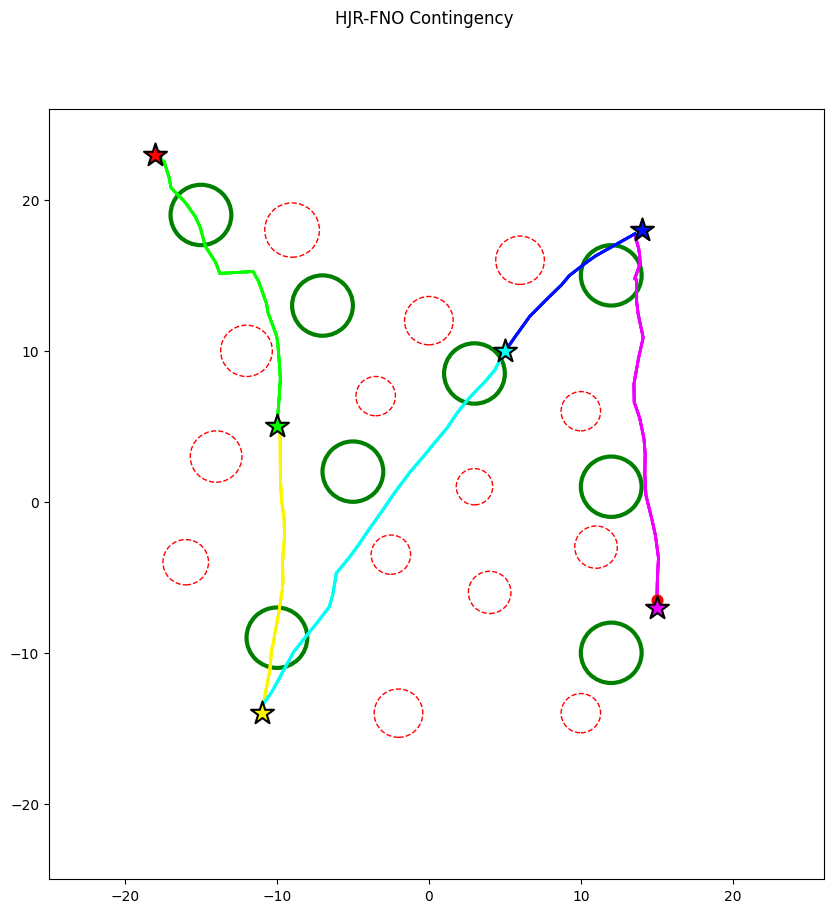

In [9]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# plotting
_fig, _ax = plt.subplots(figsize=(10, 10))
_fig.suptitle(f"HJR-FNO Contingency")
_ax.set_xlim(_env.x_range[0], _env.x_range[1]+1)
_ax.set_ylim(_env.y_range[0], _env.y_range[1]+1)    


#Color map
cmap = plt.get_cmap("hsv")
_colorList = [cmap(i) for i in np.linspace(0, 1, len(x_goal), endpoint=False)]

# restore static axis properties
_ax.set_xlim(_env.x_range[0], _env.x_range[1] + 1)
_ax.set_ylim(_env.y_range[0], _env.y_range[1] + 1)

# draw environment
_plotting.plot_env(_ax, colorList=_colorList)

# -------------------------------------------------
# Load state history
# -------------------------------------------------
file_path = "/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/exp_results/state_history.csv"

data = np.genfromtxt(file_path, delimiter=",", skip_header=1)

x_traj = data[:, 0]
y_traj = data[:, 1]
theta_traj = data[:, 2]      # not used for plotting here
goal_ids = data[:, 3].astype(int)

# -------------------------------------------------
# Plot trajectory colored by goal_id
# -------------------------------------------------
for i in range(len(x_traj) - 1):
    gid = goal_ids[i]

    _ax.plot(
        [x_traj[i], x_traj[i+1]],
        [y_traj[i], y_traj[i+1]],
        color=_colorList[gid],
        linewidth=2
    )

# Optional: plot start/end markers
_ax.scatter(x_traj[0], y_traj[0], color='black', s=60, zorder=5)
_ax.scatter(x_traj[-1], y_traj[-1], color='red', s=60, zorder=5)

plt.show()